# **Installation & Imports**

In [ ]:
# Install and import required libraries
!pip install pronouncing

import os
import pandas as pd
import pronouncing
import matplotlib.pyplot as plt
import seaborn as sns

# **Metrics Extraction Function**

In [ ]:
def analyze_line_phonology(line):
    """Counts syllables and primary stresses in a poetic line."""
    line_syllables = 0
    line_stresses = 0
    words = line.strip().split()

    for word in words:
        clean_word = word.strip(".,;:!?\"()'-—[]*").lower()
        if not clean_word:
            continue

        phones_list = pronouncing.phones_for_word(clean_word)
        if phones_list:
            stresses_str = pronouncing.stresses(phones_list[0])
            line_syllables += len(stresses_str)
            line_stresses += stresses_str.count('1')

    return line_syllables, line_stresses

# **Data Loading**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Data Analysis/data"
file_mapping = {
    "William Shakespeare": "Shakespeare.txt",
    "Emily Dickinson": "Emily_Dickinson.txt",
    "Elizabeth Barrett Browning": "Elizabeth_Barrett_Browning_Sonnets.txt"
}

compiled_data = []

for poet, file_name in file_mapping.items():
    file_path = os.path.join(base_path, file_name)
    if os.path.exists(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f, start=1):
                if not line.strip():
                    continue
                syllables, stresses = analyze_line_phonology(line)
                if syllables > 0:
                    compiled_data.append({
                        "Poet": poet,
                        "Syllables": syllables,
                        "Stresses": stresses
                    })

df = pd.DataFrame(compiled_data)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Poet,Syllables,Stresses
0,William Shakespeare,11,6
1,William Shakespeare,8,7
2,William Shakespeare,8,6
3,William Shakespeare,10,7
4,William Shakespeare,10,8


# **Descriptive Statistics**

In [ ]:
# Calculate descriptive statistics for Syllables
syllables_stats = (
    df.groupby("Poet")["Syllables"]
    .agg(["mean", "median", "std", "var", "min",
          lambda x: x.quantile(0.25),
          lambda x: x.quantile(0.75),
          "max"])
    .round(2)
)

syllables_stats.columns = [
    "Mean", "Median", "SD", "Variance", "Min",
    "0.25", "0.75", "Max"
]

print('SYLLABLES:')
syllables_stats

SYLLABLES:


,Mean,Median,SD,Variance,Min,0.25,0.75,Max
Poet,,,,,,,,
Elizabeth Barrett Browning,9.46,10.0,1.22,1.49,6,9.0,10.0,12
Emily Dickinson,6.25,6.0,1.85,3.41,1,6.0,8.0,11
William Shakespeare,9.29,10.0,1.46,2.13,1,9.0,10.0,13


In [ ]:
# Calculate descriptive statistics for Stresses
stresses_stats = (
    df.groupby("Poet")["Stresses"]
    .agg(["mean", "median", "std", "var", "min",
          lambda x: x.quantile(0.25),
          lambda x: x.quantile(0.75),
          "max"])
    .round(2)
)

stresses_stats.columns = [
    "Mean", "Median", "SD", "Variance", "Min",
    "0.25", "0.75", "Max"
]

print('STRESSES:')
stresses_stats

STRESSES:


,Mean,Median,SD,Variance,Min,0.25,0.75,Max
Poet,,,,,,,,
Elizabeth Barrett Browning,7.43,8.0,1.42,2.01,4,6.0,9.0,10
Emily Dickinson,4.09,4.0,1.51,2.27,1,3.0,5.0,10
William Shakespeare,6.99,7.0,1.58,2.49,1,6.0,8.0,11


# **Boxplots**

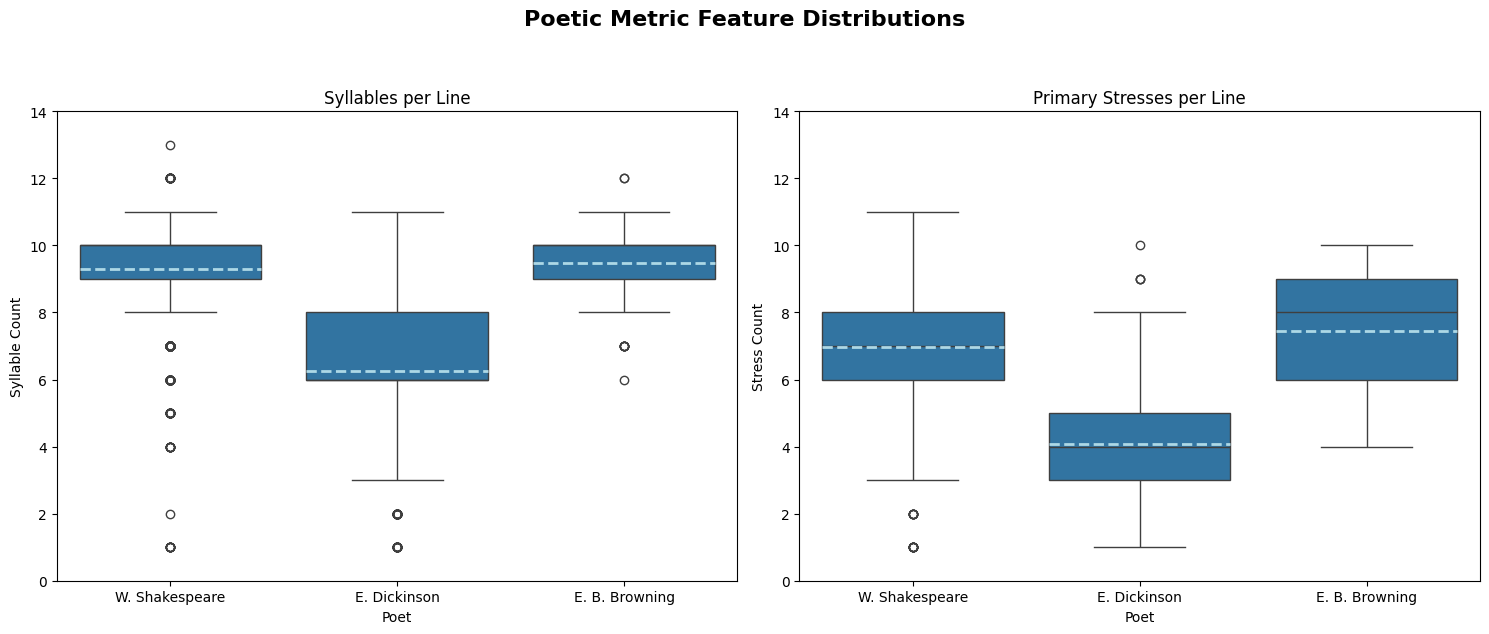

In [ ]:
name_labels = {
    "William Shakespeare": "W. Shakespeare",
    "Emily Dickinson": "E. Dickinson",
    "Elizabeth Barrett Browning": "E. B. Browning"
}
df_plotted = df.copy()
df_plotted["Poet"] = df_plotted["Poet"].map(name_labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
mean_style = {'color': 'lightblue', 'linewidth': 2}

# Syllables per Line
sns.boxplot(data=df_plotted, x="Poet", y="Syllables", showmeans=True, meanline=True, meanprops=mean_style, ax=axes[0])
axes[0].set_title("Syllables per Line", fontsize=12)
axes[0].set_xlabel("Poet", fontsize=10)
axes[0].set_ylabel("Syllable Count", fontsize=10)
axes[0].set_ylim(0, 14)

# Primary Stresses per Line
sns.boxplot(data=df_plotted, x="Poet", y="Stresses", showmeans=True, meanline=True, meanprops=mean_style, ax=axes[1])
axes[1].set_title("Primary Stresses per Line", fontsize=12)
axes[1].set_xlabel("Poet", fontsize=10)
axes[1].set_ylabel("Stress Count", fontsize=10)
axes[1].set_ylim(0, 14)

# Title
plt.suptitle(
    "Poetic Metric Feature Distributions",
    fontsize=16,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()
plt.show()

# **Histograms**

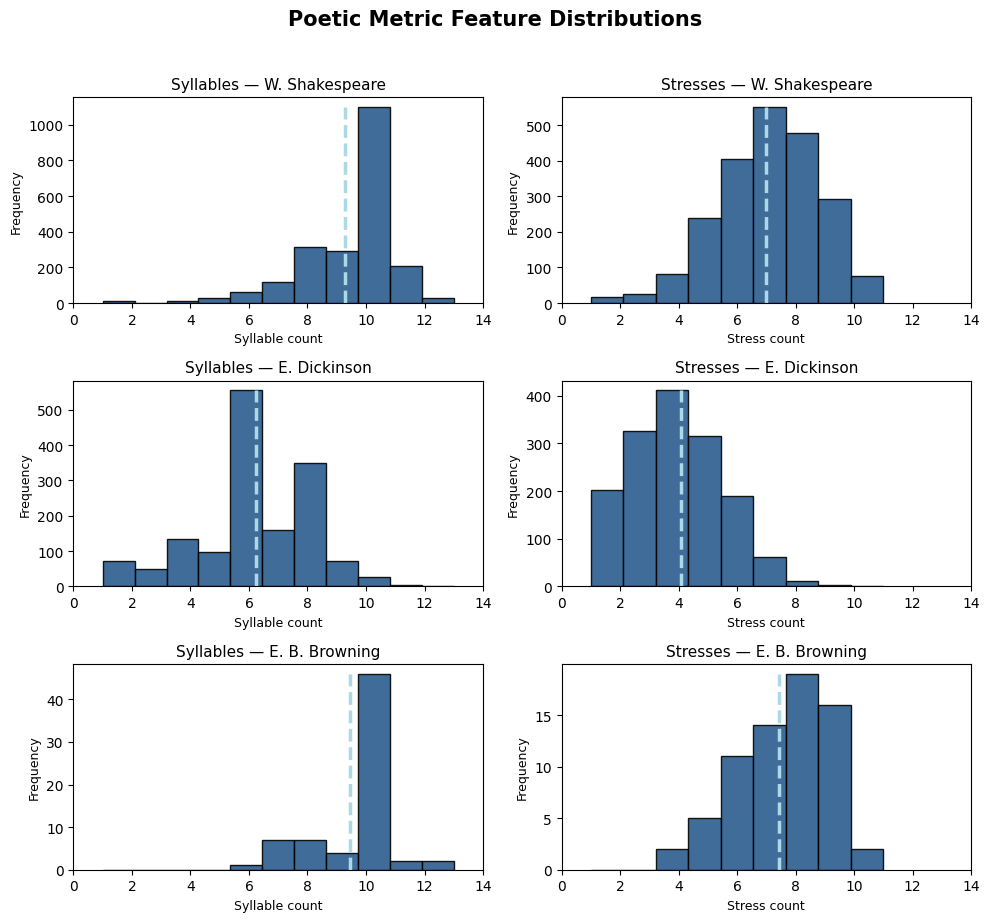

In [ ]:
name_labels = {
    "William Shakespeare": "W. Shakespeare",
    "Emily Dickinson": "E. Dickinson",
    "Elizabeth Barrett Browning": "E. B. Browning"
}
df_plotted = df.copy()
df_plotted["Poet"] = df_plotted["Poet"].map(name_labels)

syll_bins = np.linspace(df_plotted["Syllables"].min(), df_plotted["Syllables"].max(), 12)
stress_bins = np.linspace(df_plotted["Stresses"].min(), df_plotted["Stresses"].max(), 10)

fig, axes = plt.subplots(3, 2, figsize=(10, 9))

bar_color = "#2b5c8f"
mean_color = "lightblue"
poets_list = ["W. Shakespeare", "E. Dickinson", "E. B. Browning"]

for i, poet in enumerate(poets_list):
    poet_data = df_plotted[df_plotted["Poet"] == poet]

    # Syllables per Line
    syll_series = poet_data["Syllables"]
    axes[i, 0].hist(syll_series, bins=syll_bins, color=bar_color, edgecolor="black", alpha=0.9)
    syll_counts, _ = np.histogram(syll_series, bins=syll_bins)

    axes[i, 0].vlines(syll_series.mean(), 0, max(syll_counts), color=mean_color, linestyle="--", linewidth=2.5)
    axes[i, 0].set_title(f"Syllables — {poet}", fontsize=11)
    axes[i, 0].set_xlabel("Syllable count", fontsize=9)
    axes[i, 0].set_ylabel("Frequency", fontsize=9)
    axes[i, 0].set_xlim(0, 14)

    # Primary Stresses per Line
    stress_series = poet_data["Stresses"]
    axes[i, 1].hist(stress_series, bins=stress_bins, color=bar_color, edgecolor="black", alpha=0.9)
    stress_counts, _ = np.histogram(stress_series, bins=stress_bins)

    axes[i, 1].vlines(stress_series.mean(), 0, max(stress_counts), color=mean_color, linestyle="--", linewidth=2.5)
    axes[i, 1].set_title(f"Stresses — {poet}", fontsize=11)
    axes[i, 1].set_xlabel("Stress count", fontsize=9)
    axes[i, 1].set_ylabel("Frequency", fontsize=9)
    axes[i, 1].set_xlim(0, 14)

# Title
plt.suptitle(
    "Poetic Metric Feature Distributions",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()